# 1. Purpose

This notebook creates the public health summary table used for reporting. It loads the raw workbook, maps the original columns to English analysis names, derives binary indicators, computes overall and sex-stratified statistics, displays the table, exports the styled Excel workbook, and creates exploratory figures.


## Dataset Snapshot

- 845 participants total, with 437 Male and 408 Female participants.
- Four broad age groups are used for the adjusted and interaction analyses.
- Outcomes include continuous cardiometabolic, dietary, and urinary sodium measures plus binary public-health cutoff indicators.
- The notebook is the analysis workspace; the Quarto report is the presentation layer.
- The analysis goal is to summarize crude differences, assess age-adjusted associations, and check exploratory sex-by-age heterogeneity.


# 2. Analysis Parameters

Set project-relative analysis parameters once. The raw workbook remains under `data/`, generated Excel output is written under `outputs/`, and figure PNG files are written under `outputs/figures/`.


In [1]:
from pathlib import Path

# Analysis parameters
INPUT_FILE = Path("data/public_health_statistics_dataset.xlsx")
OUTPUT_EXCEL = Path("outputs/public_health_summary_table.xlsx")
FIGURE_DIR = Path("outputs/figures")
GROUP_VARIABLE = "sex_label"
GROUP_ORDER = ["Male", "Female"]
ALPHA = 0.05
DPI = 300

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

INPUT_FILE = project_root / INPUT_FILE
OUTPUT_EXCEL = project_root / OUTPUT_EXCEL
FIGURE_DIR = project_root / FIGURE_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

requested_data_path = INPUT_FILE
fallback_data_path = project_root / "data" / "24310802_public_health_statistics_dataset.xlsx"
data_path = requested_data_path if requested_data_path.exists() else fallback_data_path

output_path = OUTPUT_EXCEL
output_path.parent.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(
        "Expected data/public_health_statistics_dataset.xlsx. "
        "Fallback data/24310802_public_health_statistics_dataset.xlsx was also not found."
    )

print(f"Project root: {project_root}")
print(f"Input workbook: {data_path}")
print(f"Output workbook: {output_path}")
print(f"Figure directory: {FIGURE_DIR}")


Project root: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics
Input workbook: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics/data/24310802_public_health_statistics_dataset.xlsx
Output workbook: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics/outputs/public_health_summary_table.xlsx
Figure directory: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics/outputs/figures


In [2]:
import numpy as np
import openpyxl
import pandas as pd
from IPython.display import Markdown, display
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


# 3. Data Loading and Inspection

Detect the sample-data sheet from expected column terms, then show the workbook sheets, detected columns, sample size, and sex counts.


In [3]:
EXPECTED_SAMPLE_TERMS = [
    "年齢", "性別", "喫煙", "ＢＭＩ", "腹囲", "収縮期血圧", "中性脂肪",
    "血糖値", "野菜摂取量", "果物摂取量", "尿中ナトリウム排泄量",
    "age", "sex", "smoking", "bmi", "waist", "blood pressure",
    "triglycerides", "glucose", "vegetable", "fruit", "sodium",
]


def score_sheet_columns(workbook_path, sheet_name, expected_terms):
    """Score a sheet by matching expected analysis terms against its first rows."""
    preview = pd.read_excel(workbook_path, sheet_name=sheet_name, nrows=5, engine="openpyxl")
    normalized_columns = [str(column).strip().lower() for column in preview.columns]
    score = sum(
        any(term.lower() in column for column in normalized_columns)
        for term in expected_terms
    )
    return {
        "sheet_name": sheet_name,
        "score": score,
        "preview_rows": len(preview),
        "preview_columns": len(preview.columns),
    }


def detect_sample_sheet(workbook_path, expected_terms):
    """Return sheet diagnostics and the highest-scoring sample-data sheet name."""
    excel_file = pd.ExcelFile(workbook_path, engine="openpyxl")
    sheet_scores = [
        score_sheet_columns(workbook_path, sheet_name, expected_terms)
        for sheet_name in excel_file.sheet_names
    ]
    diagnostics = pd.DataFrame(sheet_scores).sort_values(
        ["score", "preview_columns", "preview_rows"], ascending=False
    )
    return excel_file.sheet_names, diagnostics, diagnostics.iloc[0]["sheet_name"]


sheet_names, sheet_diagnostics, sample_sheet_name = detect_sample_sheet(
    data_path, EXPECTED_SAMPLE_TERMS
)
raw_data = pd.read_excel(data_path, sheet_name=sample_sheet_name, engine="openpyxl")
raw_data.columns = [str(column).strip() for column in raw_data.columns]

print("Sheet names:")
for sheet_name in sheet_names:
    print(f"- {sheet_name}")

display(sheet_diagnostics)
print(f"Detected sample data sheet: {sample_sheet_name}")
print(f"Raw data shape: {raw_data.shape}")
print("Detected column names:")
for column_name in raw_data.columns:
    print(f"- {column_name}")


Sheet names:
- Sheet1
- Sheet2
- 1サンプルデータ
- 2ファイルレイアウト


,sheet_name,score,preview_rows,preview_columns
2,1サンプルデータ,11,5,15
1,Sheet2,0,5,3
0,Sheet1,0,5,2
3,2ファイルレイアウト,0,5,2


Detected sample data sheet: 1サンプルデータ
Raw data shape: (845, 15)
Detected column names:
- ＩＤ
- 年齢
- 年齢ｃ
- 性別
- 身長
- 体重
- 喫煙
- ＢＭＩ
- 腹囲
- 収縮期血圧
- 中性脂肪
- 血糖値
- 野菜摂取量
- 果物摂取量
- 尿中ナトリウム排泄量


In [4]:
column_map = {
    "id": "ＩＤ",
    "age": "年齢",
    "age_group": "年齢ｃ",
    "sex": "性別",
    "height": "身長",
    "weight": "体重",
    "smoking_status": "喫煙",
    "bmi": "ＢＭＩ",
    "waist_circumference": "腹囲",
    "systolic_bp": "収縮期血圧",
    "triglycerides": "中性脂肪",
    "blood_glucose": "血糖値",
    "vegetable_intake": "野菜摂取量",
    "fruit_intake": "果物摂取量",
    "urinary_sodium_excretion": "尿中ナトリウム排泄量",
}

sex_codes = {1: "Male", 2: "Female"}
age_group_codes = {1: "40s", 2: "50s", 3: "60s", 4: "70s"}
smoking_status_codes = {1: "Never smoker", 2: "Former smoker", 3: "Current smoker"}


def validate_column_map(raw_columns, mapping):
    """Raise a clear error if any mapped raw columns are missing."""
    missing_columns = [source for source in mapping.values() if source not in raw_columns]
    if missing_columns:
        raise KeyError(
            "These mapped columns were not found in the detected sheet: "
            + ", ".join(missing_columns)
            + ". Update column_map above and rerun the notebook."
        )


validate_column_map(raw_data.columns, column_map)
data = raw_data.rename(columns={source: target for target, source in column_map.items()})

print("All mapped columns were found.")
print(f"Sample size: {len(data):,}")
print("Sex counts:")
print(data["sex"].map(sex_codes).fillna(data["sex"]).value_counts(dropna=False))


All mapped columns were found.
Sample size: 845
Sex counts:
sex
Male      437
Female    408
Name: count, dtype: int64


# 4. Data Cleaning and Derived Variables

Create readable category labels and the binary indicators used for percentage rows in the summary table.


In [5]:
analysis_data = data.copy()
analysis_data["sex_label"] = analysis_data["sex"].map(sex_codes)
analysis_data["age_group_label"] = analysis_data["age_group"].map(age_group_codes)
analysis_data["smoking_status_label"] = analysis_data["smoking_status"].map(smoking_status_codes)

DERIVED_BINARY_VARIABLES = {
    "bmi_ge_25": analysis_data["bmi"] >= 25,
    "waist_above_cutoff": np.select(
        [analysis_data["sex_label"].eq("Male"), analysis_data["sex_label"].eq("Female")],
        [analysis_data["waist_circumference"] >= 85, analysis_data["waist_circumference"] >= 90],
        default=np.nan,
    ),
    "systolic_bp_ge_130": analysis_data["systolic_bp"] >= 130,
    "triglycerides_ge_150": analysis_data["triglycerides"] >= 150,
    "blood_glucose_ge_110": analysis_data["blood_glucose"] >= 110,
    "vegetable_intake_lt_350": analysis_data["vegetable_intake"] < 350,
    "fruit_intake_lt_100": analysis_data["fruit_intake"] < 100,
    "urinary_sodium_ge_4000": analysis_data["urinary_sodium_excretion"] >= 4000,
}

for column_name, values in DERIVED_BINARY_VARIABLES.items():
    analysis_data[column_name] = values

print("Rows available for analysis:", len(analysis_data))
print("Rows with recognized sex:", analysis_data["sex_label"].isin(["Male", "Female"]).sum())


Rows available for analysis: 845
Rows with recognized sex: 845


In [6]:
GROUP_NAMES = ["Overall", "Male", "Female"]
STAT_NAMES = ["Mean", "SD", "Median", "25th percentile", "75th percentile", "%"]
NOT_APPLICABLE_MARKER = "--"


def format_number(value):
    """Format numeric table values with one decimal place."""
    if pd.isna(value):
        return ""
    return f"{value:.1f}"


def format_percentage(value):
    """Format percentage table values with one decimal place."""
    if pd.isna(value):
        return ""
    return f"{value:.1f}"


def format_p_value(p_value):
    """Format p-values according to the assignment requirement."""
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "<0.001"
    return f"{p_value:.3f}"


def group_subset(group_name):
    """Return the analysis rows for one display group."""
    if group_name == "Overall":
        return analysis_data
    return analysis_data.loc[analysis_data["sex_label"].eq(group_name)]


def continuous_stats(series):
    """Calculate continuous summary statistics."""
    numeric_series = pd.to_numeric(series, errors="coerce").dropna()
    if numeric_series.empty:
        return {stat_name: "" for stat_name in STAT_NAMES}
    return {
        "Mean": format_number(numeric_series.mean()),
        "SD": format_number(numeric_series.std(ddof=1)),
        "Median": format_number(numeric_series.median()),
        "25th percentile": format_number(numeric_series.quantile(0.25)),
        "75th percentile": format_number(numeric_series.quantile(0.75)),
        "%": NOT_APPLICABLE_MARKER,
    }


def percentage_stats(series, positive_value):
    """Calculate the percentage matching a category or binary condition."""
    valid_series = series.dropna()
    if valid_series.empty:
        return {stat_name: "" for stat_name in STAT_NAMES}
    percent = valid_series.eq(positive_value).mean() * 100
    return {
        "Mean": NOT_APPLICABLE_MARKER,
        "SD": NOT_APPLICABLE_MARKER,
        "Median": NOT_APPLICABLE_MARKER,
        "25th percentile": NOT_APPLICABLE_MARKER,
        "75th percentile": NOT_APPLICABLE_MARKER,
        "%": format_percentage(percent),
    }


def mann_whitney_p_value(column_name):
    """Compare male and female distributions using the Mann-Whitney U test."""
    male_values = pd.to_numeric(
        analysis_data.loc[analysis_data["sex_label"].eq("Male"), column_name], errors="coerce"
    ).dropna()
    female_values = pd.to_numeric(
        analysis_data.loc[analysis_data["sex_label"].eq("Female"), column_name], errors="coerce"
    ).dropna()
    if male_values.empty or female_values.empty:
        return np.nan
    return stats.mannwhitneyu(male_values, female_values, alternative="two-sided").pvalue


def chi_square_p_value(column_name, positive_value):
    """Compare male and female percentages using a chi-square test."""
    subset = analysis_data.loc[
        analysis_data["sex_label"].isin(["Male", "Female"]), ["sex_label", column_name]
    ].dropna()
    if subset.empty:
        return np.nan
    subset["is_positive"] = subset[column_name].eq(positive_value)
    contingency_table = pd.crosstab(subset["sex_label"], subset["is_positive"])
    contingency_table = contingency_table.reindex(index=["Male", "Female"], columns=[False, True], fill_value=0)
    if (contingency_table.sum(axis=1) == 0).any() or (contingency_table.sum(axis=0) == 0).any():
        return np.nan
    return stats.chi2_contingency(contingency_table, correction=False).pvalue


# 5. Summary Statistics Table

Define the table rows once, then populate a MultiIndex-column DataFrame for overall, male, and female summaries. These are crude, unadjusted descriptive comparisons; age-adjusted comparisons are added later as a separate sensitivity analysis.


In [7]:
SUMMARY_COLUMNS = [("", "Variable"), ("", "Category")]
for group_name in GROUP_NAMES:
    SUMMARY_COLUMNS.extend((group_name, stat_name) for stat_name in STAT_NAMES)
SUMMARY_COLUMNS.append(("p-value", ""))

SUMMARY_ROW_SPECS = [
    ("continuous", "Age", "", "age", None, True),
    ("percentage", "Age group", "40s", "age_group_label", "40s", True),
    ("percentage", "Age group", "50s", "age_group_label", "50s", True),
    ("percentage", "Age group", "60s", "age_group_label", "60s", True),
    ("percentage", "Age group", "70s", "age_group_label", "70s", True),
    ("section", "Sex", "", None, None, False),
    ("percentage", "", "Male", "sex_label", "Male", False),
    ("percentage", "", "Female", "sex_label", "Female", False),
    ("section", "Smoking status", "", None, None, False),
    ("percentage", "", "Current smoker", "smoking_status_label", "Current smoker", True),
    ("percentage", "", "Former smoker", "smoking_status_label", "Former smoker", True),
    ("percentage", "", "Never smoker", "smoking_status_label", "Never smoker", True),
    ("continuous", "BMI", "", "bmi", None, True),
    ("percentage", "BMI", ">= 25", "bmi_ge_25", True, True),
    ("continuous", "Waist circumference", "", "waist_circumference", None, True),
    ("percentage", "Waist circumference", "Above cutoff", "waist_above_cutoff", True, True),
    ("continuous", "Systolic blood pressure", "", "systolic_bp", None, True),
    ("percentage", "Systolic blood pressure", ">= 130 mmHg", "systolic_bp_ge_130", True, True),
    ("continuous", "Triglycerides", "", "triglycerides", None, True),
    ("percentage", "Triglycerides", ">= 150 mg/dL", "triglycerides_ge_150", True, True),
    ("continuous", "Blood glucose", "", "blood_glucose", None, True),
    ("percentage", "Blood glucose", ">= 110 mg/dL", "blood_glucose_ge_110", True, True),
    ("continuous", "Vegetable intake", "", "vegetable_intake", None, True),
    ("percentage", "Vegetable intake", "< 350 g/day", "vegetable_intake_lt_350", True, True),
    ("continuous", "Fruit intake", "", "fruit_intake", None, True),
    ("percentage", "Fruit intake", "< 100 g/day", "fruit_intake_lt_100", True, True),
    ("continuous", "Urinary sodium excretion", "", "urinary_sodium_excretion", None, True),
    ("percentage", "Urinary sodium excretion", ">= 4000 mg/day", "urinary_sodium_ge_4000", True, True),
]


def empty_summary_row(variable, category=""):
    """Create one empty output row with the MultiIndex columns."""
    row = {column: "" for column in pd.MultiIndex.from_tuples(SUMMARY_COLUMNS)}
    row[("", "Variable")] = variable
    row[("", "Category")] = category
    return row


def section_summary_row(variable):
    """Create a shaded section row for categorical sections."""
    row = empty_summary_row(variable)
    for group_name in GROUP_NAMES:
        for stat_name in STAT_NAMES:
            row[(group_name, stat_name)] = NOT_APPLICABLE_MARKER
    return row


def continuous_summary_row(variable, column_name):
    """Create a row for a continuous variable."""
    row = empty_summary_row(variable)
    for group_name in GROUP_NAMES:
        for stat_name, value in continuous_stats(group_subset(group_name)[column_name]).items():
            row[(group_name, stat_name)] = value
    row[("p-value", "")] = format_p_value(mann_whitney_p_value(column_name))
    return row


def percentage_summary_row(variable, category, column_name, positive_value, include_p_value=True):
    """Create a row for a categorical or binary percentage."""
    row = empty_summary_row(variable, category)
    for group_name in GROUP_NAMES:
        for stat_name, value in percentage_stats(group_subset(group_name)[column_name], positive_value).items():
            row[(group_name, stat_name)] = value
    if include_p_value:
        row[("p-value", "")] = format_p_value(chi_square_p_value(column_name, positive_value))
    return row


def build_summary_row(row_type, variable, category, column_name, positive_value, include_p_value):
    """Dispatch one row specification to the correct row builder."""
    if row_type == "section":
        return section_summary_row(variable)
    if row_type == "continuous":
        return continuous_summary_row(variable, column_name)
    if row_type == "percentage":
        return percentage_summary_row(variable, category, column_name, positive_value, include_p_value)
    raise ValueError(f"Unknown summary row type: {row_type}")


summary_rows = [build_summary_row(*row_spec) for row_spec in SUMMARY_ROW_SPECS]
summary_table = pd.DataFrame(summary_rows)
summary_table.columns = pd.MultiIndex.from_tuples(summary_table.columns)
summary_table


Overall                  \
                    Variable        Category    Mean      SD  Median   
0                        Age                    55.8    10.2    53.0   
1                  Age group             40s      --      --      --   
2                  Age group             50s      --      --      --   
3                  Age group             60s      --      --      --   
4                  Age group             70s      --      --      --   
5                        Sex                      --      --      --   
6                                       Male      --      --      --   
7                                     Female      --      --      --   
8             Smoking status                      --      --      --   
9                             Current smoker      --      --      --   
10                             Former smoker      --      --      --   
11                              Never smoker      --      --      --   
12                       BMI                    22.9     2.8    22.8   
13                       BMI           >= 25      --      --      --   
14       Waist circumference                    77.5     7.9    76.0   
15       Waist circumference    Above cutoff      --      --      --   
16   Systolic blood pressure                   125.1    15.5   124.0   
17   Systolic blood pressure     >= 130 mmHg      --      --      --   
18             Triglycerides                   117.6    69.0   102.0   
19             Triglycerides    >= 150 mg/dL      --      --      --   
20             Blood glucose                    97.9    22.2    97.0   
21             Blood glucose    >= 110 mg/dL      --      --      --   
22          Vegetable intake                   308.6   110.4   313.0   
23          Vegetable intake     < 350 g/day      --      --      --   
24              Fruit intake                   141.4    91.9   134.5   
25              Fruit intake     < 100 g/day      --      --      --   
26  Urinary sodium excretion                  4178.2  1644.9  3881.0   
27  Urinary sodium excretion  >= 4000 mg/day      --      --      --   

                                            Male                  \
   25th percentile 75th percentile     %    Mean      SD  Median   
0             48.0            64.0    --    55.8    10.2    53.0   
1               --              --  33.3      --      --      --   
2               --              --  29.3      --      --      --   
3               --              --  20.9      --      --      --   
4               --              --  16.4      --      --      --   
5               --              --    --      --      --      --   
6               --              --  51.7      --      --      --   
7               --              --  48.3      --      --      --   
8               --              --    --      --      --      --   
9               --              --  18.2      --      --      --   
10              --              --  12.3      --      --      --   
11              --              --  69.5      --      --      --   
12            20.9            24.8    --    23.3     2.9    23.3   
13              --              --  23.6      --      --      --   
14            71.0            84.0    --    79.8     7.5    79.0   
15              --              --  18.0      --      --      --   
16           113.0           135.0    --   126.7    13.9   126.0   
17              --              --  37.5      --      --      --   
18            71.0           143.0    --   142.8    78.8   123.0   
19              --              --  22.1      --      --      --   
20            82.0           112.0    --    97.3    22.3    96.0   
21              --              --  26.9      --      --      --   
22           252.3           392.4    --   302.0   116.7   306.5   
23              --              --  61.3      --      --      --   
24            66.2           209.2    --   130.3    84.6   120.1   
25              --              --  37.9      --

In [8]:
display(summary_table)


Overall                  \
                    Variable        Category    Mean      SD  Median   
0                        Age                    55.8    10.2    53.0   
1                  Age group             40s      --      --      --   
2                  Age group             50s      --      --      --   
3                  Age group             60s      --      --      --   
4                  Age group             70s      --      --      --   
5                        Sex                      --      --      --   
6                                       Male      --      --      --   
7                                     Female      --      --      --   
8             Smoking status                      --      --      --   
9                             Current smoker      --      --      --   
10                             Former smoker      --      --      --   
11                              Never smoker      --      --      --   
12                       BMI                    22.9     2.8    22.8   
13                       BMI           >= 25      --      --      --   
14       Waist circumference                    77.5     7.9    76.0   
15       Waist circumference    Above cutoff      --      --      --   
16   Systolic blood pressure                   125.1    15.5   124.0   
17   Systolic blood pressure     >= 130 mmHg      --      --      --   
18             Triglycerides                   117.6    69.0   102.0   
19             Triglycerides    >= 150 mg/dL      --      --      --   
20             Blood glucose                    97.9    22.2    97.0   
21             Blood glucose    >= 110 mg/dL      --      --      --   
22          Vegetable intake                   308.6   110.4   313.0   
23          Vegetable intake     < 350 g/day      --      --      --   
24              Fruit intake                   141.4    91.9   134.5   
25              Fruit intake     < 100 g/day      --      --      --   
26  Urinary sodium excretion                  4178.2  1644.9  3881.0   
27  Urinary sodium excretion  >= 4000 mg/day      --      --      --   

                                            Male                  \
   25th percentile 75th percentile     %    Mean      SD  Median   
0             48.0            64.0    --    55.8    10.2    53.0   
1               --              --  33.3      --      --      --   
2               --              --  29.3      --      --      --   
3               --              --  20.9      --      --      --   
4               --              --  16.4      --      --      --   
5               --              --    --      --      --      --   
6               --              --  51.7      --      --      --   
7               --              --  48.3      --      --      --   
8               --              --    --      --      --      --   
9               --              --  18.2      --      --      --   
10              --              --  12.3      --      --      --   
11              --              --  69.5      --      --      --   
12            20.9            24.8    --    23.3     2.9    23.3   
13              --              --  23.6      --      --      --   
14            71.0            84.0    --    79.8     7.5    79.0   
15              --              --  18.0      --      --      --   
16           113.0           135.0    --   126.7    13.9   126.0   
17              --              --  37.5      --      --      --   
18            71.0           143.0    --   142.8    78.8   123.0   
19              --              --  22.1      --      --      --   
20            82.0           112.0    --    97.3    22.3    96.0   
21              --              --  26.9      --      --      --   
22           252.3           392.4    --   302.0   116.7   306.5   
23              --              --  61.3      --      --      --   
24            66.2           209.2    --   130.3    84.6   120.1   
25              --              --  37.9      --

**Interpretation.** This crude table provides the baseline descriptive view of the sample. It summarizes group composition and unadjusted Male/Female comparisons across the continuous and cutoff-based indicators, so it is best read as a reference point for the later adjusted analyses rather than as evidence of causality.

The p-values are included for the specified tests, but they should be interpreted alongside the effect sizes and the overall pattern of values rather than treated as a stand-alone decision rule.


# 6. Styled Table Display

Apply the notebook display styling used to review the summary table before export.


In [9]:
SECTION_LABELS = ["Sex", "Smoking status"]
SECTION_ROWS = summary_table.index[summary_table[("", "Variable")].isin(SECTION_LABELS)].tolist()


def body_cell_style(value):
    """Style individual body cells for notebook display."""
    if value == NOT_APPLICABLE_MARKER:
        return "background-color: #d9d9d9; color: #666666; text-align: center; border: 1px solid #808080;"
    return "border: 1px solid #808080; text-align: center;"


def row_style(row):
    """Style row labels and categorical section rows for notebook display."""
    row_styles = []
    is_section_row = row.name in SECTION_ROWS
    for column in row.index:
        if column in [("", "Variable"), ("", "Category")]:
            base_style = "border: 1px solid #808080; text-align: left; font-weight: bold;"
        else:
            base_style = "border: 1px solid #808080; text-align: center;"
        if row[column] == NOT_APPLICABLE_MARKER:
            base_style += " background-color: #d9d9d9; color: #666666;"
        if is_section_row:
            base_style += " background-color: #e2f0d9; font-weight: bold;"
        row_styles.append(base_style)
    return row_styles


styled_summary_table = (
    summary_table.style
    .hide(axis="index")
    .map(body_cell_style)
    .apply(row_style, axis=1)
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#d9eaf7"), ("border", "1px solid #808080"), ("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "th.col_heading.level0", "props": [("background-color", "#b7dee8"), ("border", "1px solid #808080"), ("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "th.col_heading.level1", "props": [("background-color", "#e2f0d9"), ("border", "1px solid #808080"), ("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "4px 6px")]},
    ])
)

display(styled_summary_table)


# 7. Excel Export

Write the summary table and sheet diagnostics, then rebuild the workbook header and formatting to match the existing Excel layout.


In [10]:
HEADER_FILL_TOP = PatternFill("solid", fgColor="B7DEE8")
HEADER_FILL_BOTTOM = PatternFill("solid", fgColor="E2F0D9")
SECTION_FILL = PatternFill("solid", fgColor="E2F0D9")
NOT_APPLICABLE_FILL = PatternFill("solid", fgColor="D9D9D9")
WHITE_FILL = PatternFill("solid", fgColor="FFFFFF")
THIN_GRAY_SIDE = Side(style="thin", color="808080")
CELL_BORDER = Border(
    left=THIN_GRAY_SIDE,
    right=THIN_GRAY_SIDE,
    top=THIN_GRAY_SIDE,
    bottom=THIN_GRAY_SIDE,
)
COLUMN_WIDTHS = {
    "A": 28, "B": 22,
    "C": 10, "D": 10, "E": 10, "F": 14, "G": 14, "H": 9,
    "I": 10, "J": 10, "K": 10, "L": 14, "M": 14, "N": 9,
    "O": 10, "P": 10, "Q": 10, "R": 14, "S": 14, "T": 9,
    "U": 10,
}


def write_workbook_tables(summary, diagnostics, workbook_path):
    """Write the raw summary and diagnostics sheets before applying workbook styles."""
    with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Summary table", index=True, merge_cells=False)
        diagnostics.to_excel(writer, sheet_name="Sheet diagnostics", index=False)


def rebuild_summary_header(worksheet):
    """Replace pandas' flattened MultiIndex export with the two-row report header."""
    worksheet.delete_cols(1)
    worksheet.insert_rows(2)
    for column_number in range(1, worksheet.max_column + 1):
        worksheet.cell(row=1, column=column_number).value = None
        worksheet.cell(row=2, column=column_number).value = None

    worksheet["A1"] = "Variable"
    worksheet["B1"] = "Category"
    worksheet["C1"] = "Overall"
    worksheet["I1"] = "Male"
    worksheet["O1"] = "Female"
    worksheet["U1"] = "p-value"
    for start_column in [3, 9, 15]:
        for offset, stat_name in enumerate(STAT_NAMES):
            worksheet.cell(row=2, column=start_column + offset).value = stat_name

    worksheet.delete_rows(3, 2)
    for merge_range in ["A1:A2", "B1:B2", "C1:H1", "I1:N1", "O1:T1", "U1:U2"]:
        worksheet.merge_cells(merge_range)


def apply_summary_sheet_style(worksheet):
    """Apply borders, fills, alignment, widths, and freeze panes."""
    for row in worksheet.iter_rows():
        for cell in row:
            cell.border = CELL_BORDER
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            if cell.row in [1, 2]:
                cell.font = Font(bold=True)
                cell.fill = HEADER_FILL_TOP if cell.row == 1 else HEADER_FILL_BOTTOM

    for row_number in range(3, worksheet.max_row + 1):
        variable_cell = worksheet.cell(row=row_number, column=1)
        category_cell = worksheet.cell(row=row_number, column=2)
        variable_cell.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        category_cell.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        variable_cell.font = Font(bold=True)

        is_section_row = variable_cell.value in SECTION_LABELS and not category_cell.value
        for column_number in range(1, worksheet.max_column + 1):
            cell = worksheet.cell(row=row_number, column=column_number)
            if cell.value == NOT_APPLICABLE_MARKER:
                cell.fill = NOT_APPLICABLE_FILL
                cell.font = Font(color="666666")
            elif is_section_row:
                cell.fill = SECTION_FILL
                cell.font = Font(bold=True)
            else:
                cell.fill = WHITE_FILL

    for column_letter, width in COLUMN_WIDTHS.items():
        worksheet.column_dimensions[column_letter].width = width

    worksheet.freeze_panes = "C3"
    worksheet.sheet_view.showGridLines = False


def export_styled_summary_workbook(summary, diagnostics, workbook_path):
    """Export the styled workbook used for reporting."""
    write_workbook_tables(summary, diagnostics, workbook_path)
    workbook = openpyxl.load_workbook(workbook_path)
    worksheet = workbook["Summary table"]
    rebuild_summary_header(worksheet)
    apply_summary_sheet_style(worksheet)
    workbook.save(workbook_path)


export_styled_summary_workbook(summary_table, sheet_diagnostics, output_path)
print(f"Exported styled Excel table to: {output_path}")


Exported styled Excel table to: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics/outputs/public_health_summary_table.xlsx


# 8. Exploratory Visualizations

The following figures provide simple visual checks of the main continuous measures and cutoff-based prevalence patterns. Each plot uses a clean white background and readable publication-style formatting with matplotlib only.

Boxplots show distributions by sex. Bar chart error bars show approximate 95% confidence intervals for proportions. P-values compare Male vs Female groups using the same crude, unadjusted tests as the summary table.


In [11]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.size": 11,
})

sex_order = GROUP_ORDER
sex_colors = ["#4C78A8", "#F58518"]
group_sample_sizes = (
    analysis_data[GROUP_VARIABLE]
    .value_counts()
    .reindex(GROUP_ORDER)
    .fillna(0)
    .astype(int)
)
group_sample_size_label = ", ".join(
    f"{group} (n={group_sample_sizes.loc[group]:,})" for group in GROUP_ORDER
)


def save_figure(fig, filename):
    """Save a matplotlib figure to the configured figure directory."""
    figure_path = FIGURE_DIR / filename
    fig.savefig(figure_path, dpi=DPI, bbox_inches="tight", facecolor="white")
    return figure_path


def p_value_label(p_value):
    """Return a compact p-value label for plot annotations."""
    formatted = format_p_value(p_value)
    return "p = unavailable" if formatted == "" else f"p = {formatted}"


def sex_grouped_values(column_name):
    """Return numeric values by sex for matplotlib boxplots."""
    return [
        pd.to_numeric(
            analysis_data.loc[analysis_data[GROUP_VARIABLE].eq(sex), column_name],
            errors="coerce",
        ).dropna()
        for sex in sex_order
    ]


def style_boxplot(boxplot):
    for patch, color in zip(boxplot["boxes"], sex_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor("#333333")
    for median in boxplot["medians"]:
        median.set_color("#111111")
        median.set_linewidth(1.6)
    for whisker in boxplot["whiskers"]:
        whisker.set_color("#333333")
    for cap in boxplot["caps"]:
        cap.set_color("#333333")


def cutoff_percentage_ci(column_name, sex):
    """Return percent, 95% CI half-width, and n for a binary cutoff indicator."""
    values = analysis_data.loc[analysis_data[GROUP_VARIABLE].eq(sex), column_name].dropna()
    n = len(values)
    if n == 0:
        return np.nan, np.nan, 0
    p = values.eq(True).mean()
    se = np.sqrt(p * (1 - p) / n)
    return p * 100, 1.96 * se * 100, n


def join_or_none(values):
    """Return a readable list or a none-found phrase."""
    return ", ".join(values) if values else "none of the selected variables"


print(f"Figures will be saved to: {FIGURE_DIR}")


Figures will be saved to: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics/outputs/figures


## Figure 1. BMI Distribution by Sex

Caption: BMI distributions are shown for Male and Female participants. The figure title reports group sample sizes and the Mann-Whitney U-test p-value.


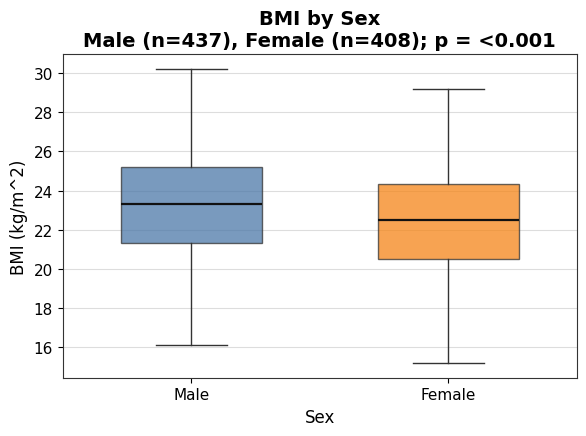

In [12]:
bmi_p_value = mann_whitney_p_value("bmi")

fig, ax = plt.subplots(figsize=(6, 4.5))
boxplot = ax.boxplot(
    sex_grouped_values("bmi"),
    tick_labels=sex_order,
    patch_artist=True,
    widths=0.55,
    showfliers=False,
)
style_boxplot(boxplot)
ax.set_title(f"BMI by Sex\n{group_sample_size_label}; {p_value_label(bmi_p_value)}")
ax.set_xlabel("Sex")
ax.set_ylabel("BMI (kg/m^2)")
ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
fig.tight_layout()
save_figure(fig, "fig1_bmi_by_sex.png")
plt.show()


**Interpretation.** BMI appears broadly similar across Male and Female groups, with substantial within-group spread in both boxplots. The p-value in the title is from a crude unadjusted comparison, so it should be read as descriptive evidence rather than proof of a practically important difference. Any visible separation is modest relative to the variability within each group.


## Figure 2. Blood Glucose Distribution by Sex

Caption: Blood glucose distributions are shown for Male and Female participants. The figure title reports group sample sizes and the Mann-Whitney U-test p-value.


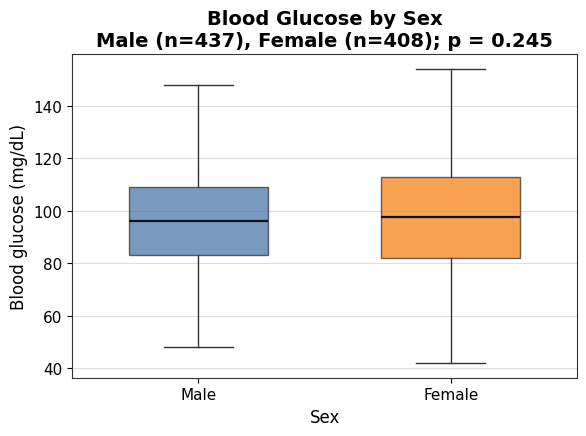

In [13]:
blood_glucose_p_value = mann_whitney_p_value("blood_glucose")

fig, ax = plt.subplots(figsize=(6, 4.5))
boxplot = ax.boxplot(
    sex_grouped_values("blood_glucose"),
    tick_labels=sex_order,
    patch_artist=True,
    widths=0.55,
    showfliers=False,
)
style_boxplot(boxplot)
ax.set_title(
    "Blood Glucose by Sex\n"
    f"{group_sample_size_label}; {p_value_label(blood_glucose_p_value)}"
)
ax.set_xlabel("Sex")
ax.set_ylabel("Blood glucose (mg/dL)")
ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
fig.tight_layout()
save_figure(fig, "fig2_blood_glucose_by_sex.png")
plt.show()


**Interpretation.** Blood glucose shows the same basic distributional comparison framework as BMI, but the plot makes it easier to see whether one sex tends to sit higher or lower across the interquartile range. The crude p-value is useful for orientation, although the plot itself is more informative about magnitude and overlap than the binary significance label. As with the other unadjusted figures, the result should be interpreted as a descriptive comparison.


## Figure 3. Age Group Percentages

Caption: Bars show the overall percentage of participants in each age group. No p-value is shown because this figure summarizes the overall sample rather than comparing groups.


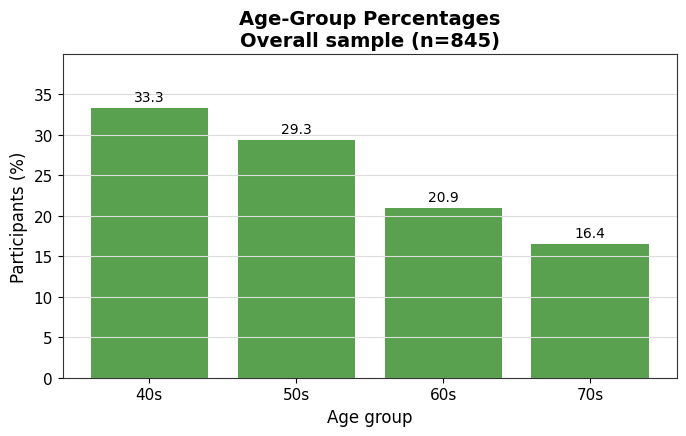

In [14]:
age_group_percentages = (
    analysis_data["age_group_label"]
    .dropna()
    .value_counts(normalize=True)
    .reindex(["40s", "50s", "60s", "70s"])
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(age_group_percentages.index, age_group_percentages.values, color="#59A14F")
ax.set_title(f"Age-Group Percentages\nOverall sample (n={len(analysis_data):,})")
ax.set_xlabel("Age group")
ax.set_ylabel("Participants (%)")
ax.set_ylim(0, max(age_group_percentages.max() * 1.2, 10))
ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10)
fig.tight_layout()
save_figure(fig, "fig3_age_group_percentages.png")
plt.show()


**Interpretation.** The age-group bar chart describes the composition of the sample rather than a group comparison. Any later age-adjusted analysis should be interpreted in light of this structure, because the crude sex contrasts may partly reflect the distribution of participants across age groups. The figure therefore provides context for the regression analyses that follow.


## Figure 4. Prevalence Above Cutoff Values by Sex

Caption: Bars show sex-specific percentages meeting each cutoff definition, including urinary sodium as `Sodium >= 4000 mg/day`. Error bars show approximate 95% confidence intervals for proportions, and right-side annotations report chi-square p-values comparing Male and Female groups.


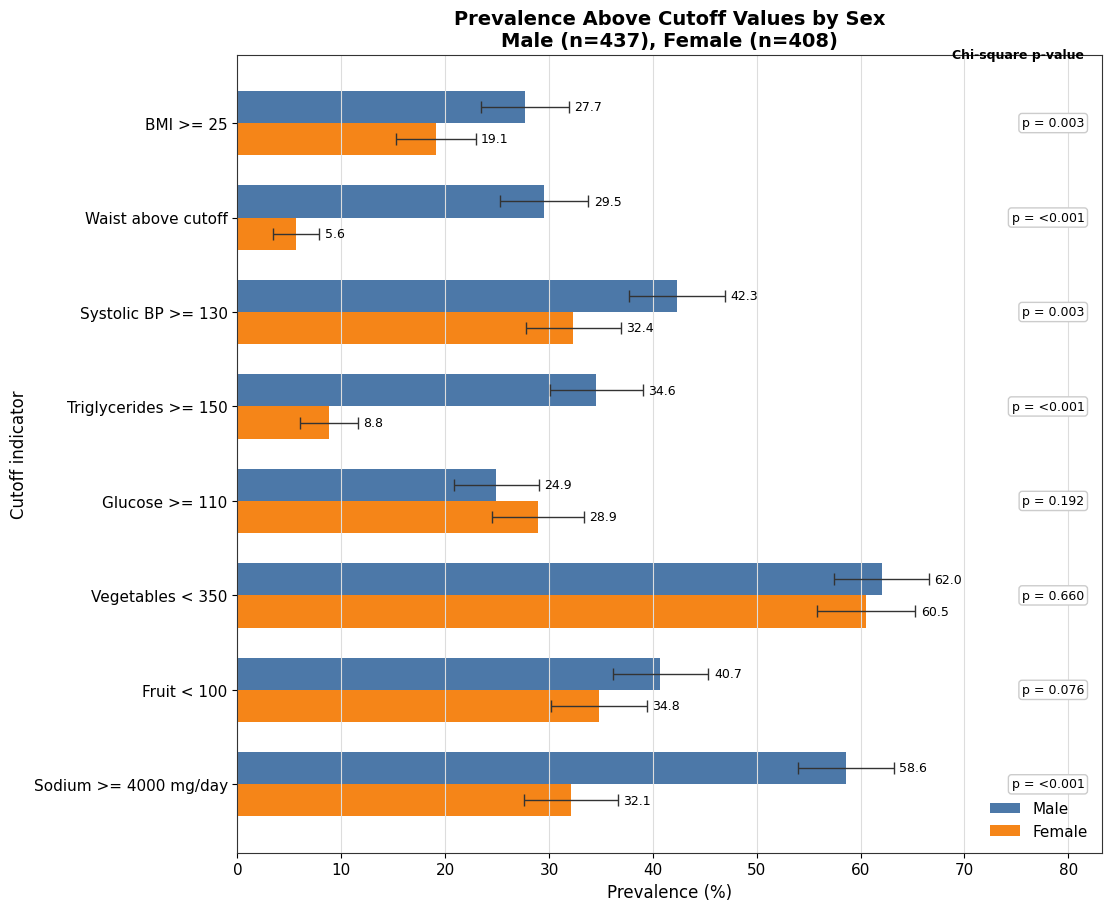

In [15]:
cutoff_indicators = {
    "BMI >= 25": "bmi_ge_25",
    "Waist above cutoff": "waist_above_cutoff",
    "Systolic BP >= 130": "systolic_bp_ge_130",
    "Triglycerides >= 150": "triglycerides_ge_150",
    "Glucose >= 110": "blood_glucose_ge_110",
    "Vegetables < 350": "vegetable_intake_lt_350",
    "Fruit < 100": "fruit_intake_lt_100",
    "Sodium >= 4000 mg/day": "urinary_sodium_ge_4000",
}

prevalence_by_sex = pd.DataFrame(index=cutoff_indicators.keys(), columns=sex_order, dtype=float)
prevalence_ci_by_sex = pd.DataFrame(index=cutoff_indicators.keys(), columns=sex_order, dtype=float)
sample_size_by_sex = pd.DataFrame(index=cutoff_indicators.keys(), columns=sex_order, dtype=int)

for label, column_name in cutoff_indicators.items():
    for sex in sex_order:
        percent, ci_half_width, n = cutoff_percentage_ci(column_name, sex)
        prevalence_by_sex.loc[label, sex] = percent
        prevalence_ci_by_sex.loc[label, sex] = ci_half_width
        sample_size_by_sex.loc[label, sex] = n

cutoff_p_values = pd.Series(
    {
        label: p_value_label(chi_square_p_value(column_name, True))
        for label, column_name in cutoff_indicators.items()
    }
)

indicator_labels = prevalence_by_sex.index.tolist()
y = np.arange(len(indicator_labels))
bar_height = 0.34

fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
male_bars = ax.barh(
    y - bar_height / 2,
    prevalence_by_sex["Male"],
    bar_height,
    xerr=prevalence_ci_by_sex["Male"],
    capsize=4,
    label="Male",
    color=sex_colors[0],
    error_kw={"elinewidth": 1.0, "ecolor": "#333333"},
)
female_bars = ax.barh(
    y + bar_height / 2,
    prevalence_by_sex["Female"],
    bar_height,
    xerr=prevalence_ci_by_sex["Female"],
    capsize=4,
    label="Female",
    color=sex_colors[1],
    error_kw={"elinewidth": 1.0, "ecolor": "#333333"},
)
ax.set_title(f"Prevalence Above Cutoff Values by Sex\n{group_sample_size_label}")
ax.set_xlabel("Prevalence (%)")
ax.set_ylabel("Cutoff indicator")
ax.set_yticks(y)
ax.set_yticklabels(indicator_labels)
ax.invert_yaxis()
right_limit = min(max((prevalence_by_sex + prevalence_ci_by_sex).max().max() * 1.25, 55), 100)
ax.set_xlim(0, right_limit)
ax.grid(axis="x", color="#DDDDDD", linewidth=0.8)
ax.legend(frameon=False, loc="lower right")
ax.bar_label(male_bars, fmt="%.1f", padding=4, fontsize=9)
ax.bar_label(female_bars, fmt="%.1f", padding=4, fontsize=9)

p_value_x = right_limit * 0.98
for row_number, label in enumerate(indicator_labels):
    ax.text(
        p_value_x,
        row_number,
        cutoff_p_values.loc[label],
        ha="right",
        va="center",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#CCCCCC"},
    )
ax.text(
    p_value_x,
    -0.72,
    "Chi-square p-value",
    ha="right",
    va="center",
    fontsize=9,
    fontweight="bold",
)
save_figure(fig, "fig4_cutoff_prevalence_by_sex.png")
plt.show()


**Interpretation.** This figure places several binary health-related indicators on the same percentage scale, which makes the broad sex pattern easier to compare across outcomes. The error bars show approximate uncertainty around each prevalence estimate, and the chi-square p-values describe the crude Male vs Female comparisons only. Differences that look visually larger are not necessarily more important clinically, so the plot is best read as a compact descriptive summary.


# 9. Age-Adjusted Sensitivity Analysis

The crude comparisons above may partly reflect differences in age-group composition. This section re-estimates the Male vs Female contrasts after adjusting for categorical age group to assess whether the observed patterns persist once broad demographic structure is taken into account. Continuous outcomes use linear regression models, and binary cutoff indicators use logistic regression models. These models are sensitivity analyses, not causal models; results should be interpreted cautiously because this is an observational descriptive dataset. Small cell counts may make some logistic regression estimates unstable.


In [16]:
import statsmodels.formula.api as smf

AGE_ADJUSTED_OUTPUT = project_root / "outputs" / "age_adjusted_sensitivity_analysis.xlsx"

continuous_age_adjusted_outcomes = {
    "BMI": "bmi",
    "Systolic blood pressure": "systolic_bp",
    "Triglycerides": "triglycerides",
    "Blood glucose": "blood_glucose",
    "Urinary sodium excretion": "urinary_sodium_excretion",
}

binary_age_adjusted_outcomes = {
    "BMI >= 25": "bmi_ge_25",
    "Waist circumference above cutoff": "waist_above_cutoff",
    "Systolic BP >= 130": "systolic_bp_ge_130",
    "Triglycerides >= 150": "triglycerides_ge_150",
    "Blood glucose >= 110": "blood_glucose_ge_110",
    "Vegetable intake < 350": "vegetable_intake_lt_350",
    "Fruit intake < 100": "fruit_intake_lt_100",
    "Sodium >= 4000": "urinary_sodium_ge_4000",
}


def sex_model_term(model):
    """Return the Female-vs-Male coefficient name from a fitted model."""
    matching_terms = [term for term in model.params.index if "sex_label" in term and "Female" in term]
    if not matching_terms:
        raise KeyError("Could not find the Female vs Male model coefficient.")
    return matching_terms[0]


def age_adjusted_linear_row(outcome_label, column_name):
    """Fit an age-adjusted linear model and return the sex coefficient row."""
    model_data = analysis_data[[column_name, "sex_label", "age_group"]].dropna().copy()
    model_data = model_data.loc[model_data["sex_label"].isin(GROUP_ORDER)]
    model_data[column_name] = pd.to_numeric(model_data[column_name], errors="coerce")
    model_data = model_data.dropna(subset=[column_name])
    formula = f'{column_name} ~ C(sex_label, Treatment(reference="Male")) + C(age_group)'
    model = smf.ols(formula, data=model_data).fit()
    term = sex_model_term(model)
    confidence_interval = model.conf_int().loc[term]
    return {
        "Outcome type": "Continuous",
        "Outcome": outcome_label,
        "Model": "Linear regression",
        "Contrast": "Female vs Male",
        "Estimate": model.params[term],
        "Estimate type": "Coefficient",
        "95% CI lower": confidence_interval.iloc[0],
        "95% CI upper": confidence_interval.iloc[1],
        "p-value": format_p_value(model.pvalues[term]),
        "Model N": int(model.nobs),
    }


def age_adjusted_logistic_row(outcome_label, column_name):
    """Fit an age-adjusted logistic model and return the sex odds-ratio row."""
    model_data = analysis_data[[column_name, "sex_label", "age_group"]].dropna().copy()
    model_data = model_data.loc[model_data["sex_label"].isin(GROUP_ORDER)]
    model_data["cutoff_outcome"] = model_data[column_name].astype(int)
    formula = 'cutoff_outcome ~ C(sex_label, Treatment(reference="Male")) + C(age_group)'
    model = smf.logit(formula, data=model_data).fit(disp=False)
    term = sex_model_term(model)
    confidence_interval = model.conf_int().loc[term]
    return {
        "Outcome type": "Binary cutoff",
        "Outcome": outcome_label,
        "Model": "Logistic regression",
        "Contrast": "Female vs Male",
        "Estimate": np.exp(model.params[term]),
        "Estimate type": "Odds ratio",
        "95% CI lower": np.exp(confidence_interval.iloc[0]),
        "95% CI upper": np.exp(confidence_interval.iloc[1]),
        "p-value": format_p_value(model.pvalues[term]),
        "Model N": int(model.nobs),
    }


age_adjusted_rows = [
    age_adjusted_linear_row(outcome_label, column_name)
    for outcome_label, column_name in continuous_age_adjusted_outcomes.items()
]
age_adjusted_rows.extend(
    age_adjusted_logistic_row(outcome_label, column_name)
    for outcome_label, column_name in binary_age_adjusted_outcomes.items()
)

age_adjusted_results = pd.DataFrame(age_adjusted_rows)
age_adjusted_results["Estimate"] = age_adjusted_results["Estimate"].round(3)
age_adjusted_results["95% CI lower"] = age_adjusted_results["95% CI lower"].round(3)
age_adjusted_results["95% CI upper"] = age_adjusted_results["95% CI upper"].round(3)

display(age_adjusted_results)
age_adjusted_results.to_excel(AGE_ADJUSTED_OUTPUT, index=False)
print(f"Exported age-adjusted sensitivity analysis to: {AGE_ADJUSTED_OUTPUT}")


,Outcome type,Outcome,Model,Contrast,Estimate,Estimate type,95% CI lower,95% CI upper,p-value,Model N
0,Continuous,BMI,Linear regression,Female vs Male,-0.804,Coefficient,-1.183,-0.425,<0.001,845
1,Continuous,Systolic blood pressure,Linear regression,Female vs Male,-3.605,Coefficient,-5.658,-1.551,<0.001,845
2,Continuous,Triglycerides,Linear regression,Female vs Male,-52.101,Coefficient,-60.762,-43.440,<0.001,845
3,Continuous,Blood glucose,Linear regression,Female vs Male,1.181,Coefficient,-1.817,4.180,0.440,845
4,Continuous,Urinary sodium excretion,Linear regression,Female vs Male,-914.502,Coefficient,-1128.256,-700.747,<0.001,845
5,Binary cutoff,BMI >= 25,Logistic regression,Female vs Male,0.608,Odds ratio,0.439,0.842,0.003,845
6,Binary cutoff,Waist circumference above cutoff,Logistic regression,Female vs Male,0.140,Odds ratio,0.087,0.223,<0.001,845
7,Binary cutoff,Systolic BP >= 130,Logistic regression,Female vs Male,0.634,Odds ratio,0.477,0.843,0.002,845
8,Binary cutoff,Triglycerides >= 150,Logistic regression,Female vs Male,0.184,Odds ratio,0.124,0.273,<0.001,845
9,Binary cutoff,Blood glucose >= 110,Logistic regression,Female vs Male,1.210,Odds ratio,0.891,1.643,0.223,845


Exported age-adjusted sensitivity analysis to: /Volumes/OWC Envoy Pro FX/Learning/public-health-statistics/outputs/age_adjusted_sensitivity_analysis.xlsx


**Interpretation.** The age-adjusted table summarizes the Female vs Male contrasts after controlling for categorical age group. Comparing these estimates with the crude table helps identify where age composition may explain part of the unadjusted difference and where the association appears more stable. The confidence intervals and p-values should be interpreted as model-based uncertainty measures, not as proof of practical importance.


## Figure 5. Age-Adjusted Standardized Mean Differences for Continuous Outcomes

Caption: Figure 5 shows age-adjusted standardized Female vs Male mean differences for continuous outcomes. Estimates are adjusted for categorical age group only, shown in standard-deviation units, and presented as sensitivity analyses, not causal effects.


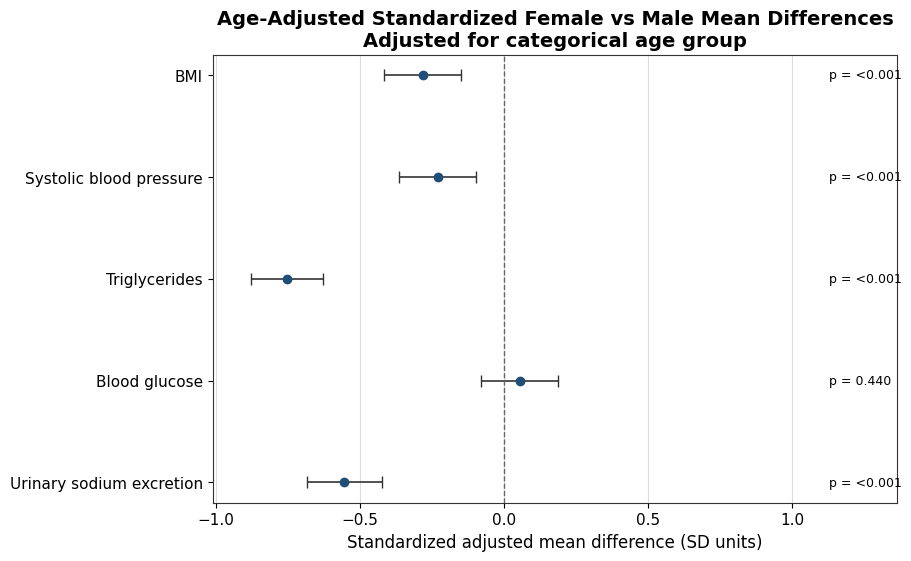

In [17]:
def standardized_age_adjusted_linear_row(outcome_label, column_name):
    """Fit an age-adjusted linear model using a z-scored continuous outcome."""
    model_data = analysis_data[[column_name, "sex_label", "age_group"]].dropna().copy()
    model_data = model_data.loc[model_data["sex_label"].isin(GROUP_ORDER)]
    model_data[column_name] = pd.to_numeric(model_data[column_name], errors="coerce")
    model_data = model_data.dropna(subset=[column_name])

    outcome_mean = model_data[column_name].mean()
    outcome_sd = model_data[column_name].std()
    if pd.isna(outcome_sd) or np.isclose(outcome_sd, 0):
        raise ValueError(f"Cannot standardize {outcome_label}: standard deviation is zero or missing.")

    model_data["z_outcome"] = (model_data[column_name] - outcome_mean) / outcome_sd
    formula = 'z_outcome ~ C(sex_label, Treatment(reference="Male")) + C(age_group)'
    model = smf.ols(formula, data=model_data).fit()
    term = sex_model_term(model)
    confidence_interval = model.conf_int().loc[term]

    return {
        "Outcome": outcome_label,
        "Estimate": model.params[term],
        "95% CI lower": confidence_interval.iloc[0],
        "95% CI upper": confidence_interval.iloc[1],
        "p-value": format_p_value(model.pvalues[term]),
        "Model N": int(model.nobs),
    }


continuous_forest_data = pd.DataFrame(
    standardized_age_adjusted_linear_row(outcome_label, column_name)
    for outcome_label, column_name in continuous_age_adjusted_outcomes.items()
)
continuous_forest_data[["Estimate", "95% CI lower", "95% CI upper"]] = continuous_forest_data[
    ["Estimate", "95% CI lower", "95% CI upper"]
].round(3)
continuous_forest_data = continuous_forest_data.iloc[::-1].reset_index(drop=True)

y = np.arange(len(continuous_forest_data))
x_errors = np.vstack([
    continuous_forest_data["Estimate"] - continuous_forest_data["95% CI lower"],
    continuous_forest_data["95% CI upper"] - continuous_forest_data["Estimate"],
])

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ax.errorbar(
    continuous_forest_data["Estimate"],
    y,
    xerr=x_errors,
    fmt="o",
    color="#1F4E79",
    ecolor="#333333",
    elinewidth=1.2,
    capsize=4,
)
ax.axvline(0, color="#666666", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(continuous_forest_data["Outcome"])
ax.set_xlabel("Standardized adjusted mean difference (SD units)")
ax.set_title("Age-Adjusted Standardized Female vs Male Mean Differences\nAdjusted for categorical age group")
ax.grid(axis="x", color="#DDDDDD", linewidth=0.8)

x_limit = np.nanmax(np.abs(continuous_forest_data[["95% CI lower", "95% CI upper"]].to_numpy()))
ax.set_xlim(-x_limit * 1.15, x_limit * 1.55)
p_value_x = x_limit * 1.28
for row_number, row in continuous_forest_data.iterrows():
    ax.text(
        p_value_x,
        row_number,
        f"p = {row['p-value']}",
        ha="left",
        va="center",
        fontsize=9,
    )

save_figure(fig, "fig5_age_adjusted_mean_differences.png")
plt.show()


**Interpretation.** Figure 5 shows age-adjusted standardized mean differences from linear regression. The continuous outcomes are standardized because BMI, blood pressure, triglycerides, blood glucose, and urinary sodium excretion are measured in different units and ranges. Each point estimates the Female vs Male difference after accounting for categorical age group, interpreted in standard-deviation units rather than original measurement units. This makes cross-outcome visual comparison more meaningful, while the confidence intervals and p-values still describe model-based uncertainty. P-values should not be read as practical importance by themselves, and these remain descriptive adjusted associations rather than causal effects.


## Figure 6. Age-Adjusted Odds Ratios for Binary Cutoff Outcomes

Caption: Figure 6 shows age-adjusted Female vs Male odds ratios for binary cutoff outcomes. Estimates are adjusted for categorical age group only and are presented as sensitivity analyses, not causal effects.


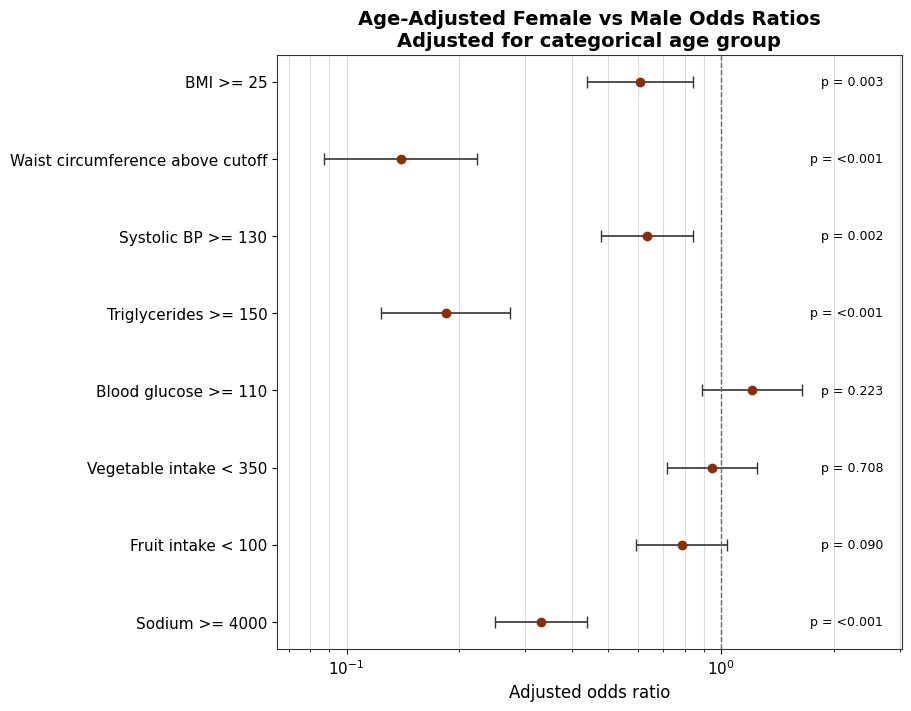

In [18]:
binary_forest_data = age_adjusted_results.loc[
    age_adjusted_results["Outcome type"].eq("Binary cutoff")
].copy()
binary_forest_data = binary_forest_data.iloc[::-1].reset_index(drop=True)

y = np.arange(len(binary_forest_data))
x_errors = np.vstack([
    binary_forest_data["Estimate"] - binary_forest_data["95% CI lower"],
    binary_forest_data["95% CI upper"] - binary_forest_data["Estimate"],
])

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
ax.errorbar(
    binary_forest_data["Estimate"],
    y,
    xerr=x_errors,
    fmt="o",
    color="#8C2D04",
    ecolor="#333333",
    elinewidth=1.2,
    capsize=4,
)
ax.axvline(1, color="#666666", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y)
ax.set_yticklabels(binary_forest_data["Outcome"])
ax.set_xlabel("Adjusted odds ratio")
ax.set_title("Age-Adjusted Female vs Male Odds Ratios\nAdjusted for categorical age group")
ax.grid(axis="x", color="#DDDDDD", linewidth=0.8, which="both")

x_min = max(binary_forest_data["95% CI lower"].min() * 0.75, 0.03)
x_max = binary_forest_data["95% CI upper"].max() * 1.85
ax.set_xlim(x_min, x_max)
p_value_x = x_max / 1.12
for row_number, row in binary_forest_data.iterrows():
    ax.text(
        p_value_x,
        row_number,
        f"p = {row['p-value']}",
        ha="right",
        va="center",
        fontsize=9,
    )

save_figure(fig, "fig6_age_adjusted_odds_ratios.png")
plt.show()


**Interpretation.** Figure 6 shows age-adjusted odds ratios from logistic regression for binary threshold outcomes, so each estimate describes how the odds of meeting a public-health cutoff differ between Female and Male participants after adjusting for categorical age group. Values above 1 indicate higher adjusted odds in Female participants and values below 1 indicate lower adjusted odds, but the substantive meaning depends on the specific threshold definition. This complements Figure 5 by translating the same sex comparison into prevalence-oriented outcomes rather than continuous measurements. Confidence intervals convey uncertainty, and some estimates may attenuate after age adjustment or remain imprecise when subgroup counts are limited.


# 10. Sex-by-Age Interaction Analysis

The age-adjusted models ask whether overall sex differences persist after accounting for age group. This section now focuses on a single primary interaction figure for the continuous outcomes, which keeps the report focused while still checking whether the Female vs Male contrast varies across age strata. The goal is to flag possible subgroup heterogeneity, not to produce a primary inferential result. Continuous outcomes use linear regression models with sex-by-age-group interaction terms, and binary cutoff outcomes use logistic regression models with the same interaction structure. Interaction terms are exploratory and should not be interpreted as causal effects. Subgroup sample sizes may be limited, especially for binary outcomes.


In [19]:
interaction_continuous_outcomes = continuous_age_adjusted_outcomes.copy()
interaction_binary_outcomes = binary_age_adjusted_outcomes.copy()


def interaction_terms(model):
    """Return sex-by-age interaction term names from a fitted model."""
    return [term for term in model.params.index if ":" in term and "sex_label" in term and "age_group" in term]


def clean_interaction_term(term):
    """Create a readable interaction-term label from a statsmodels parameter name."""
    age_part = term.split(":")[-1]
    age_label = age_part.split("[T.")[-1].rstrip("]")
    return f"Female vs Male difference in age group {age_label} vs reference age group"


def interaction_linear_rows(outcome_label, column_name):
    """Fit a linear interaction model and return interaction coefficient rows."""
    model_data = analysis_data[[column_name, "sex_label", "age_group"]].dropna().copy()
    model_data = model_data.loc[model_data["sex_label"].isin(GROUP_ORDER)]
    model_data[column_name] = pd.to_numeric(model_data[column_name], errors="coerce")
    model_data = model_data.dropna(subset=[column_name])
    formula = f'{column_name} ~ C(sex_label, Treatment(reference="Male")) * C(age_group)'
    model = smf.ols(formula, data=model_data).fit()
    rows = []
    for term in interaction_terms(model):
        confidence_interval = model.conf_int().loc[term]
        rows.append({
            "Outcome type": "Continuous",
            "Outcome": outcome_label,
            "Model": "Linear regression interaction",
            "Interaction term": clean_interaction_term(term),
            "Estimate": model.params[term],
            "Estimate type": "Coefficient",
            "95% CI lower": confidence_interval.iloc[0],
            "95% CI upper": confidence_interval.iloc[1],
            "Interaction p-value": format_p_value(model.pvalues[term]),
            "Model N": int(model.nobs),
        })
    return rows


def interaction_logistic_rows(outcome_label, column_name):
    """Fit a logistic interaction model and return interaction odds-ratio rows."""
    model_data = analysis_data[[column_name, "sex_label", "age_group"]].dropna().copy()
    model_data = model_data.loc[model_data["sex_label"].isin(GROUP_ORDER)]
    model_data["cutoff_outcome"] = model_data[column_name].astype(int)
    formula = 'cutoff_outcome ~ C(sex_label, Treatment(reference="Male")) * C(age_group)'
    model = smf.logit(formula, data=model_data).fit(disp=False)
    rows = []
    for term in interaction_terms(model):
        confidence_interval = model.conf_int().loc[term]
        rows.append({
            "Outcome type": "Binary cutoff",
            "Outcome": outcome_label,
            "Model": "Logistic regression interaction",
            "Interaction term": clean_interaction_term(term),
            "Estimate": np.exp(model.params[term]),
            "Estimate type": "Odds ratio",
            "95% CI lower": np.exp(confidence_interval.iloc[0]),
            "95% CI upper": np.exp(confidence_interval.iloc[1]),
            "Interaction p-value": format_p_value(model.pvalues[term]),
            "Model N": int(model.nobs),
        })
    return rows


interaction_rows = []
for outcome_label, column_name in interaction_continuous_outcomes.items():
    interaction_rows.extend(interaction_linear_rows(outcome_label, column_name))
for outcome_label, column_name in interaction_binary_outcomes.items():
    interaction_rows.extend(interaction_logistic_rows(outcome_label, column_name))

interaction_results = pd.DataFrame(interaction_rows)
interaction_results["Estimate"] = interaction_results["Estimate"].round(3)
interaction_results["95% CI lower"] = interaction_results["95% CI lower"].round(3)
interaction_results["95% CI upper"] = interaction_results["95% CI upper"].round(3)

display(interaction_results)


,Outcome type,Outcome,Model,Interaction term,Estimate,Estimate type,95% CI lower,95% CI upper,Interaction p-value,Model N
0,Continuous,BMI,Linear regression interaction,Female vs Male difference in age group 2 vs re...,0.337,Coefficient,-0.625,1.298,0.492,845
1,Continuous,BMI,Linear regression interaction,Female vs Male difference in age group 3 vs re...,-0.064,Coefficient,-1.121,0.994,0.906,845
2,Continuous,BMI,Linear regression interaction,Female vs Male difference in age group 4 vs re...,-0.158,Coefficient,-1.300,0.985,0.787,845
3,Continuous,Systolic blood pressure,Linear regression interaction,Female vs Male difference in age group 2 vs re...,1.745,Coefficient,-3.431,6.920,0.508,845
4,Continuous,Systolic blood pressure,Linear regression interaction,Female vs Male difference in age group 3 vs re...,9.377,Coefficient,3.684,15.070,0.001,845
5,Continuous,Systolic blood pressure,Linear regression interaction,Female vs Male difference in age group 4 vs re...,6.063,Coefficient,-0.087,12.213,0.053,845
6,Continuous,Triglycerides,Linear regression interaction,Female vs Male difference in age group 2 vs re...,21.584,Coefficient,-0.315,43.482,0.053,845
7,Continuous,Triglycerides,Linear regression interaction,Female vs Male difference in age group 3 vs re...,27.883,Coefficient,3.795,51.971,0.023,845
8,Continuous,Triglycerides,Linear regression interaction,Female vs Male difference in age group 4 vs re...,25.156,Coefficient,-0.865,51.178,0.058,845
9,Continuous,Blood glucose,Linear regression interaction,Female vs Male difference in age group 2 vs re...,3.533,Coefficient,-4.068,11.133,0.362,845


**Interpretation.** The interaction table reports whether the Female vs Male contrast changes across age groups relative to the reference age group. Non-zero interaction terms suggest possible effect heterogeneity, but wide intervals or unstable estimates are common in subgroup analyses and should be expected here. This table is therefore best treated as exploratory evidence for where subgroup patterns may differ, not as a definitive interaction screen.


## Figure 7. Sex-by-Age Patterns for Continuous Outcomes

Caption: Figure 7 shows mean values with approximate 95% confidence intervals by age group and sex for the continuous outcomes. These plots are exploratory subgroup visualizations for the interaction analysis.


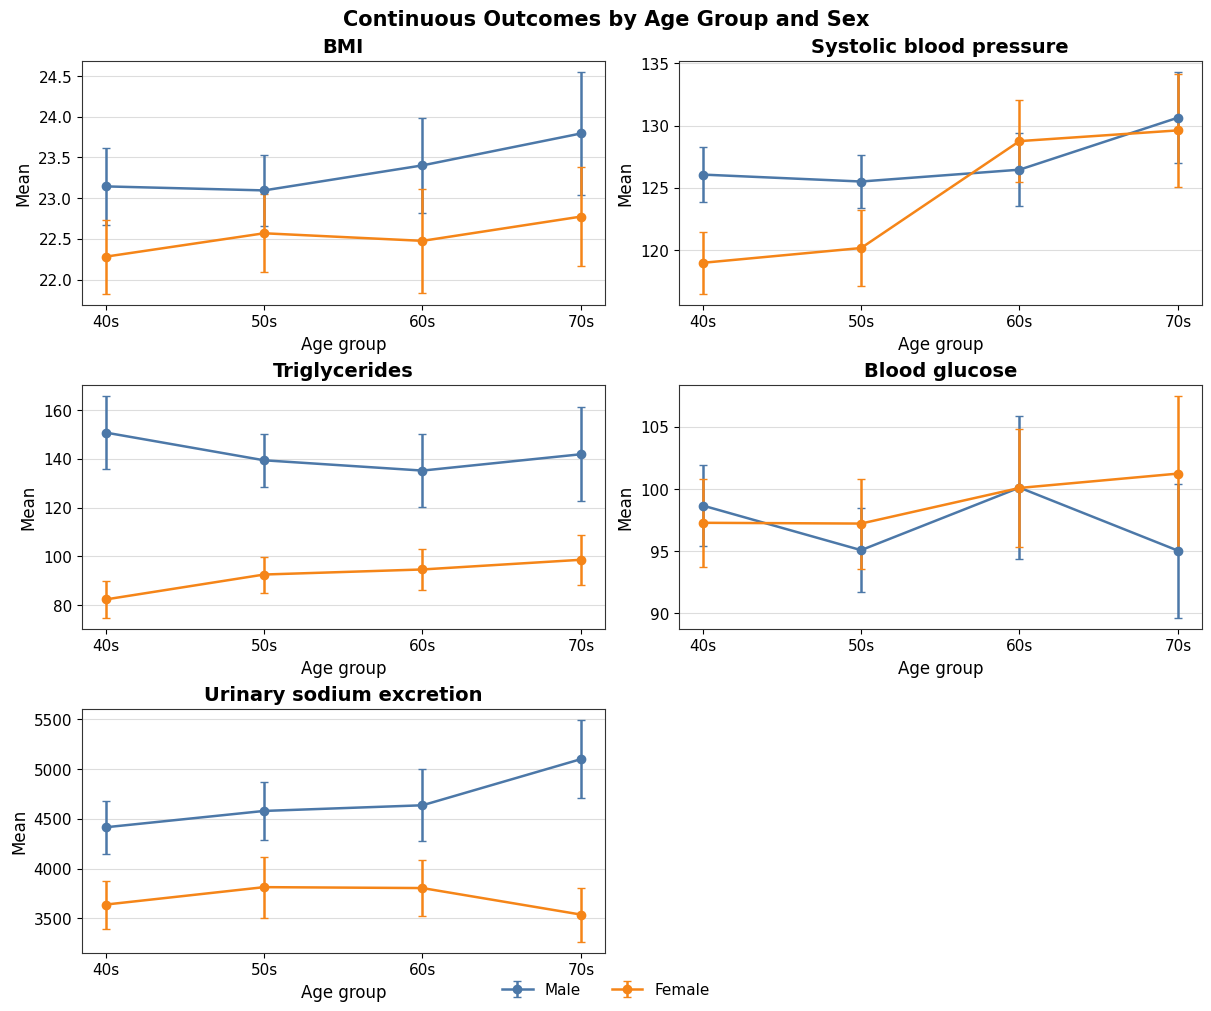

In [20]:
age_group_order = ["40s", "50s", "60s", "70s"]
continuous_plot_outcomes = list(interaction_continuous_outcomes.items())
fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

for ax, (outcome_label, column_name) in zip(axes, continuous_plot_outcomes):
    plot_data = analysis_data[[column_name, "sex_label", "age_group_label"]].dropna().copy()
    plot_data = plot_data.loc[plot_data["sex_label"].isin(GROUP_ORDER)]
    plot_data[column_name] = pd.to_numeric(plot_data[column_name], errors="coerce")
    summary = (
        plot_data.groupby(["age_group_label", "sex_label"])[column_name]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary["ci"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
    for sex, color in zip(GROUP_ORDER, sex_colors):
        sex_summary = summary.loc[summary["sex_label"].eq(sex)].set_index("age_group_label").reindex(age_group_order)
        ax.errorbar(
            age_group_order,
            sex_summary["mean"],
            yerr=sex_summary["ci"],
            marker="o",
            linewidth=1.8,
            capsize=3,
            label=sex,
            color=color,
        )
    ax.set_title(outcome_label)
    ax.set_xlabel("Age group")
    ax.set_ylabel("Mean")
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)

for ax in axes[len(continuous_plot_outcomes):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
fig.suptitle("Continuous Outcomes by Age Group and Sex", fontsize=15, fontweight="bold")
save_figure(fig, "fig7_interaction_continuous_outcomes.png")
plt.show()


**Interpretation.** The continuous-outcome interaction plots show how the mean level of each outcome changes across age groups within each sex. Roughly parallel lines suggest little evidence that sex differences vary much by age, whereas separated or crossing lines suggest possible heterogeneity. Because each age-sex subgroup can be small, the uncertainty bands are important for judging how much weight to place on any apparent pattern.


# 11. Results


### Main Findings

The crude summary table and exploratory figures provide the primary descriptive view of the dataset. These unadjusted results compare Male and Female groups directly and show differences in several cardiometabolic, dietary, and urinary sodium measures. The cutoff-prevalence figure is useful for comparing the direction and magnitude of group differences across multiple public health indicators on the same percentage scale.

The age-adjusted sensitivity analysis adds a second perspective by accounting for categorical age group. Figures 5 and 6 summarize the adjusted Female vs Male contrasts for continuous outcomes and binary cutoff outcomes. These adjusted estimates should be read alongside the crude table and figures: some crude differences may remain similar after age adjustment, while others may attenuate when age-group composition is taken into account.

The interaction analysis is intentionally secondary. Figure 7 provides the subgroup-heterogeneity view for the continuous outcomes and is retained as an exploratory check on whether sex differences look broadly consistent across age strata.

### Statistical Notes

P-values reflect evidence under the specified tests or regression models, but statistical significance does not imply practical or public health importance. Confidence intervals should be interpreted alongside point estimates because they show the direction and precision of estimated differences. The age-adjusted and interaction models are sensitivity analyses adjusted for categorical age group only. Interaction analyses are exploratory and should be interpreted as subgroup-pattern checks rather than confirmatory evidence.


# 12. Discussion

This analysis is best interpreted as a descriptive public health summary rather than a causal analysis. The crude table and figures describe observed Male and Female group differences, while the age-adjusted models ask whether those comparisons look similar after accounting for broad age-group differences. The interaction figure then asks whether the continuous-outcome sex differences appear stable across age groups.

Age group is a plausible demographic confounder in this setting because many cardiometabolic and dietary measures vary with age. The age-adjusted forest plots therefore provide a useful sensitivity check, but they do not control for other potential confounders such as medication use, socioeconomic factors, clinical history, or health behaviors beyond the variables already summarized.

The sex-by-age interaction analysis extends the descriptive workflow by asking whether sex differences vary across age strata. These subgroup patterns are useful for hypothesis generation, but interaction terms can be unstable when cell counts are limited. They should be interpreted separately from main sex effects and treated as exploratory evidence of possible heterogeneity.

Mann-Whitney U tests were used for crude continuous comparisons because normality was not assumed, and chi-square tests were used for crude categorical and binary comparisons. The regression models provide age-adjusted and interaction sensitivity analyses, not causal estimates. Results should be interpreted as associations or descriptive differences that depend on data quality, coding consistency, and the assignment-specific cutoff definitions used to derive binary indicators.
